<a href="https://colab.research.google.com/github/psychic-coder/NLP-Sentiment-Analysis-College-/blob/main/NLP_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries loaded successfully!
Loading dataset...
✅ Dataset loaded successfully!
Total reviews: 50000
Columns: ['review', 'sentiment']

First 2 rows:
Sample size: 5000
Positive reviews: 2519
Negative reviews: 2481

✅ Data prepared!
Processing reviews (this may take 1-2 minutes)...
✅ Text preprocessing completed!

📝 Sample Original Review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...

✨ Sample Cleaned Review:
realli like summerslam due look arena curtain look overal interest reason anyway could one best summerslam ever wwf didnt lex luger main event yokozuna time huge fat man strong man glad time chang ter...
Converting text to TF-IDF features...
✅ Feature matrix shape: (5000, 5000)

📊 Data Split:
Training samples: 4000
Test samples: 1000
✅ Model training completed!

         SENTIMENT ANALYSIS RESULTS

🎯 MODEL ACCURACY: 84.

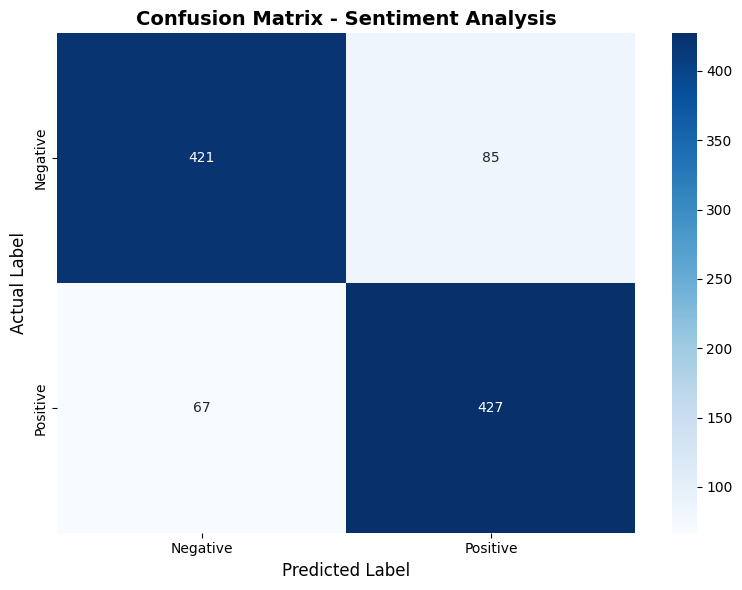

✅ Confusion matrix saved as 'confusion_matrix.png'

🔍 TESTING MODEL WITH NEW REVIEWS:


📝 Review: This movie was absolutely fantastic! Great acting and amazing storyline.
🎯 Sentiment: POSITIVE 😊
💪 Confidence: 76.99%

📝 Review: Terrible waste of time. Worst movie I have ever seen.
🎯 Sentiment: NEGATIVE 😞
💪 Confidence: 97.88%

📝 Review: The product is okay, nothing special but it works.
🎯 Sentiment: NEGATIVE 😞
💪 Confidence: 72.36%

📝 Review: I love this! Highly recommended to everyone.
🎯 Sentiment: POSITIVE 😊
💪 Confidence: 86.48%

📝 Review: Not bad at all, actually quite good.
🎯 Sentiment: NEGATIVE 😞
💪 Confidence: 57.64%

✅ Model and vectorizer saved successfully!
Files created: 'sentiment_model.pkl' and 'vectorizer.pkl'

📚 MOST INFORMATIVE WORDS:
👍 Positive indicators: abandon, abbott, abil, abl, abl see, absolut love, academi, academi award, accept
👎 Negative indicators: abc, abomin, abraham, absenc, absolut, absolut noth, absurd, abus, abysm, accent


In [3]:
# ============================================
# CELL 1: Installations and Imports
# ============================================
!pip install pandas scikit-learn nltk matplotlib seaborn -q

import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

print("✅ All libraries loaded successfully!")

# ============================================
# CELL 2: Load Dataset (WORKING ALTERNATIVE)
# ============================================
# Option A: Use a reliable IMDB dataset from GitHub
print("Loading dataset...")

# This is a clean, publicly available dataset of 50k IMDB reviews
!wget -q https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv -O imdb_reviews.csv

# Load the dataset
df = pd.read_csv('imdb_reviews.csv')
print(f"✅ Dataset loaded successfully!")
print(f"Total reviews: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 2 rows:")
df.head(2)

# ============================================
# CELL 3: Data Preparation
# ============================================
# Rename columns for convenience
df.columns = ['review', 'sentiment']

# Convert sentiment to binary (positive=1, negative=0)
df['sentiment_binary'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# Take a balanced subset for faster training (5000 reviews)
df_sample = df.sample(n=5000, random_state=42)
print(f"Sample size: {len(df_sample)}")
print(f"Positive reviews: {(df_sample['sentiment_binary']==1).sum()}")
print(f"Negative reviews: {(df_sample['sentiment_binary']==0).sum()}")
print("\n✅ Data prepared!")

# ============================================
# CELL 4: Text Preprocessing Function
# ============================================
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Clean and preprocess text data"""
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize
    words = word_tokenize(text)
    # Remove stopwords and stem
    words = [stemmer.stem(word) for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

print("Processing reviews (this may take 1-2 minutes)...")
df_sample['cleaned_review'] = df_sample['review'].apply(clean_text)
print("✅ Text preprocessing completed!")

# Display sample
print("\n📝 Sample Original Review:")
print(df_sample['review'].iloc[0][:200] + "...")
print("\n✨ Sample Cleaned Review:")
print(df_sample['cleaned_review'].iloc[0][:200] + "...")

# ============================================
# CELL 5: Feature Extraction with TF-IDF
# ============================================
X = df_sample['cleaned_review']
y = df_sample['sentiment_binary']

# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(
    max_features=5000,      # Use top 5000 words
    ngram_range=(1, 2),     # Use unigrams and bigrams
    min_df=2,               # Ignore words that appear less than 2 times
    max_df=0.95             # Ignore words that appear in >95% of documents
)

print("Converting text to TF-IDF features...")
X_vectorized = vectorizer.fit_transform(X)
print(f"✅ Feature matrix shape: {X_vectorized.shape}")

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

print(f"\n📊 Data Split:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# ============================================
# CELL 6: Train Naïve Bayes Model
# ============================================
# Initialize and train the model
model = MultinomialNB(alpha=1.0)  # alpha=1.0 for Laplace smoothing
model.fit(X_train, y_train)

print("✅ Model training completed!")

# Make predictions
y_pred = model.predict(X_test)

# ============================================
# CELL 7: Model Evaluation
# ============================================
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n" + "="*50)
print("         SENTIMENT ANALYSIS RESULTS")
print("="*50)
print(f"\n🎯 MODEL ACCURACY: {accuracy:.2%}")
print(f"📈 Total Test Samples: {len(y_test)}")

# Print confusion matrix
print("\n📊 CONFUSION MATRIX:")
print("-" * 40)
print("                 Predicted")
print("              Negative   Positive")
print(f"Actual Negative   {conf_matrix[0,0]:5d}    {conf_matrix[0,1]:5d}")
print(f"Actual Positive   {conf_matrix[1,0]:5d}    {conf_matrix[1,1]:5d}")
print("-" * 40)

# Calculate additional metrics
tn, fp, fn, tp = conf_matrix.ravel()
precision_pos = tp / (tp + fp)
recall_pos = tp / (tp + fn)
precision_neg = tn / (tn + fn)
recall_neg = tn / (tn + fp)

print(f"\n📈 DETAILED METRICS:")
print(f"Positive Class - Precision: {precision_pos:.2%}, Recall: {recall_pos:.2%}")
print(f"Negative Class - Precision: {precision_neg:.2%}, Recall: {recall_neg:.2%}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# ============================================
# CELL 8: Visualize Confusion Matrix (for PPT)
# ============================================
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Sentiment Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved as 'confusion_matrix.png'")

# ============================================
# CELL 9: Test with Custom Reviews
# ============================================
def predict_sentiment(review_text):
    """Predict sentiment of a single review"""
    # Clean the review
    cleaned = clean_text(review_text)
    # Vectorize
    vectorized = vectorizer.transform([cleaned])
    # Predict
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]

    sentiment = "POSITIVE 😊" if prediction == 1 else "NEGATIVE 😞"
    confidence = max(probability) * 100

    print("\n" + "="*50)
    print(f"📝 Review: {review_text}")
    print(f"🎯 Sentiment: {sentiment}")
    print(f"💪 Confidence: {confidence:.2f}%")
    print("="*50)
    return sentiment

# Test with various examples
print("\n🔍 TESTING MODEL WITH NEW REVIEWS:\n")

predict_sentiment("This movie was absolutely fantastic! Great acting and amazing storyline.")
predict_sentiment("Terrible waste of time. Worst movie I have ever seen.")
predict_sentiment("The product is okay, nothing special but it works.")
predict_sentiment("I love this! Highly recommended to everyone.")
predict_sentiment("Not bad at all, actually quite good.")

# ============================================
# CELL 10: Save Model for Deployment (Optional)
# ============================================
import pickle

# Save the model and vectorizer
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("\n✅ Model and vectorizer saved successfully!")
print("Files created: 'sentiment_model.pkl' and 'vectorizer.pkl'")

# Show top features (most informative words)
feature_names = vectorizer.get_feature_names_out()
coefs = model.feature_log_prob_

# Get top positive and negative words
positive_words = []
negative_words = []
for idx, word in enumerate(feature_names[:20]):  # Show top 20
    pos_prob = coefs[1][idx]  # Positive class probability
    neg_prob = coefs[0][idx]  # Negative class probability
    if pos_prob > neg_prob:
        positive_words.append(word)
    else:
        negative_words.append(word)

print("\n📚 MOST INFORMATIVE WORDS:")
print(f"👍 Positive indicators: {', '.join(positive_words[:10])}")
print(f"👎 Negative indicators: {', '.join(negative_words[:10])}")